In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

print("Libraries Loaded")

Libraries Loaded


In [2]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print("Fund Master:", fund_master.shape)

print("NAV:", nav_history.shape)

print("AUM:", aum.shape)

print("SIP:", sip.shape)

print("Transactions:", transactions.shape)

print("Portfolio:", portfolio.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/01_fund_master.csv'

In [3]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print("Fund Master:", fund_master.shape)

print("NAV:", nav_history.shape)

print("AUM:", aum.shape)

print("SIP:", sip.shape)

print("Transactions:", transactions.shape)

print("Portfolio:", portfolio.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/01_fund_master.csv'

In [4]:
fund_master = pd.read_csv(
    "data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "data/raw/02_nav_history.csv"
)

aum = pd.read_csv(
    "data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "data/raw/04_monthly_sip_inflows.csv"
)

transactions = pd.read_csv(
    "data/raw/08_investor_transactions.csv"
)

portfolio = pd.read_csv(
    "data/raw/09_portfolio_holdings.csv"
)

print("Fund Master:", fund_master.shape)

print("NAV:", nav_history.shape)

print("AUM:", aum.shape)

print("SIP:", sip.shape)

print("Transactions:", transactions.shape)

print("Portfolio:", portfolio.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Transactions: (32778, 13)
Portfolio: (322, 8)


In [5]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_plot = nav_history.merge(

    fund_master[
        ["amfi_code","scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

fig = px.line(

    nav_plot,

    x="date",

    y="nav",

    color="scheme_name",

    title="Daily NAV Trend 2022-2026"

)

fig.show()

In [6]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

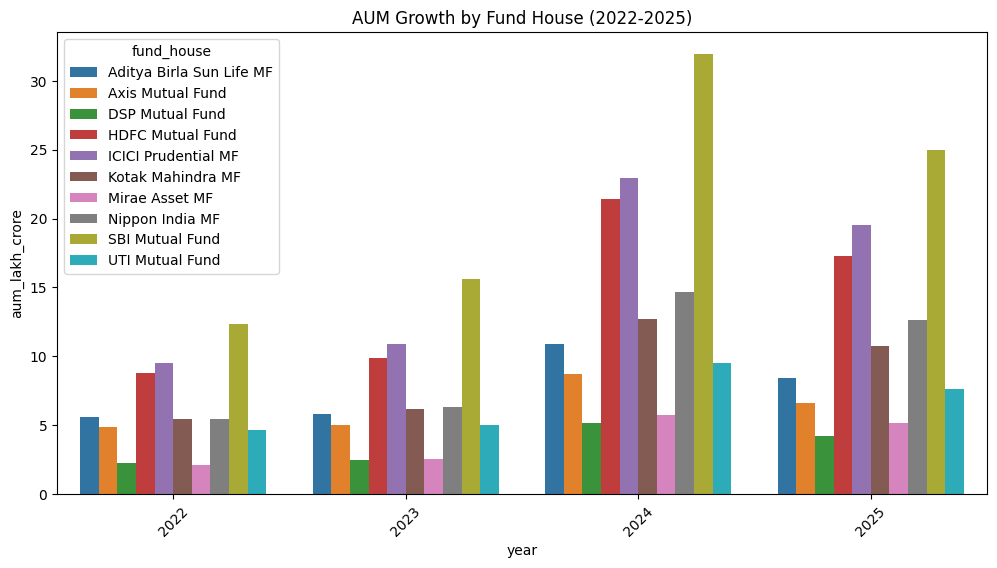

In [7]:
aum["date"] = pd.to_datetime(
    aum["date"]
)

aum["year"] = aum[
    "date"
].dt.year

aum_year = aum.groupby(

    ["year","fund_house"]

)["aum_lakh_crore"].sum().reset_index()

plt.figure(
    figsize=(12,6)
)

sns.barplot(

    data=aum_year,

    x="year",

    y="aum_lakh_crore",

    hue="fund_house"

)

plt.title(
    "AUM Growth by Fund House (2022-2025)"
)

plt.xticks(
    rotation=45
)

plt.show()


In [8]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [9]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(

    sip,

    x="month",

    y="sip_inflow_crore",

    title="Monthly SIP Inflow Trend (2022-2025)",

    markers=True

)

fig.add_annotation(

    x=sip.loc[
        sip["sip_inflow_crore"].idxmax(),
        "month"
    ],

    y=sip["sip_inflow_crore"].max(),

    text="Highest SIP Inflow",

    showarrow=True

)

fig.show()

In [10]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

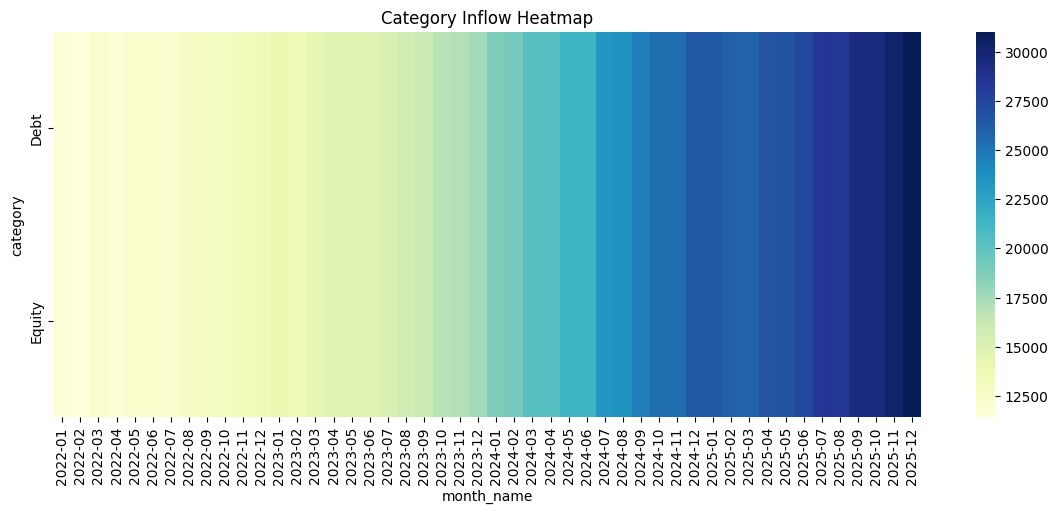

In [11]:
category_data = fund_master[
    ["category"]
].copy()

category_data["key"] = 1

sip_copy = sip.copy()

sip_copy["key"] = 1

heatmap_df = category_data.merge(

    sip_copy,

    on="key"

)

heatmap_df["month_name"] = heatmap_df[
    "month"
].dt.strftime("%Y-%m")

pivot_table = heatmap_df.pivot_table(

    values="sip_inflow_crore",

    index="category",

    columns="month_name",

    aggfunc="mean"

)

plt.figure(
    figsize=(14,5)
)

sns.heatmap(

    pivot_table,

    cmap="YlGnBu"

)

plt.title(
    "Category Inflow Heatmap"
)

plt.show()

In [12]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

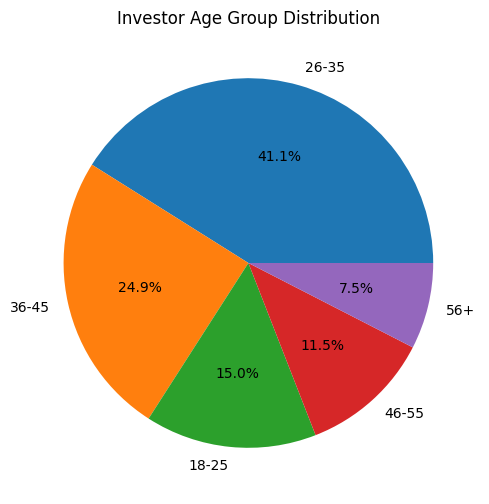

In [13]:
age_counts = transactions[
    "age_group"
].value_counts()

plt.figure(
    figsize=(6,6)
)

plt.pie(

    age_counts,

    labels=age_counts.index,

    autopct="%1.1f%%"

)

plt.title(
    "Investor Age Group Distribution"
)

plt.show()

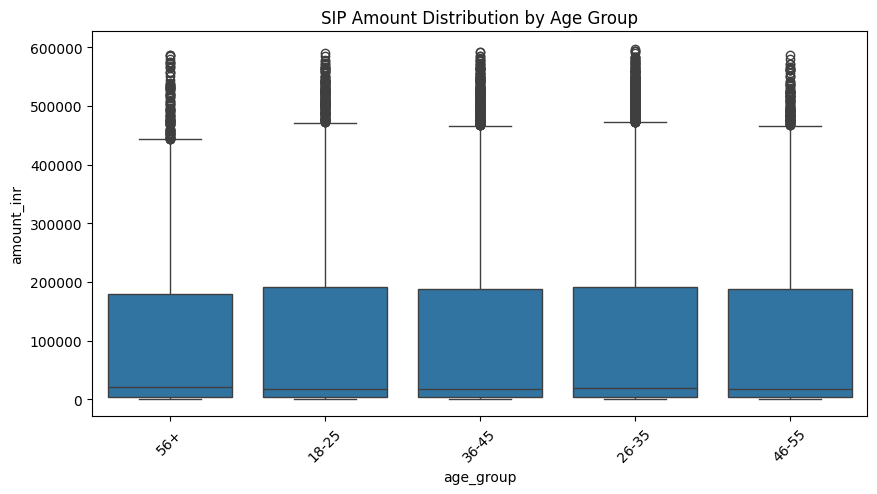

In [14]:
plt.figure(
    figsize=(10,5)
)

sns.boxplot(

    data=transactions,

    x="age_group",

    y="amount_inr"

)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.xticks(
    rotation=45
)

plt.show()

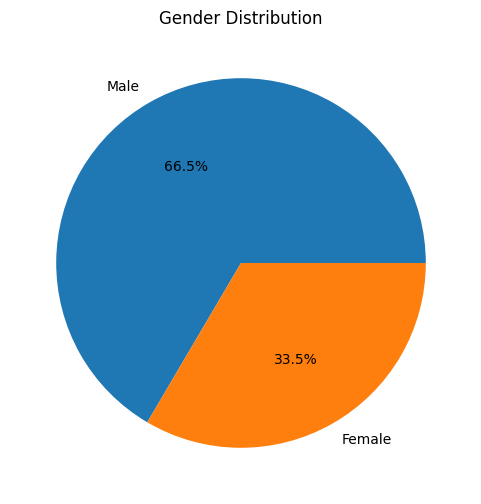

In [15]:
gender_counts = transactions[
    "gender"
].value_counts()

plt.figure(
    figsize=(6,6)
)

plt.pie(

    gender_counts,

    labels=gender_counts.index,

    autopct="%1.1f%%"

)

plt.title(
    "Gender Distribution"
)

plt.show()

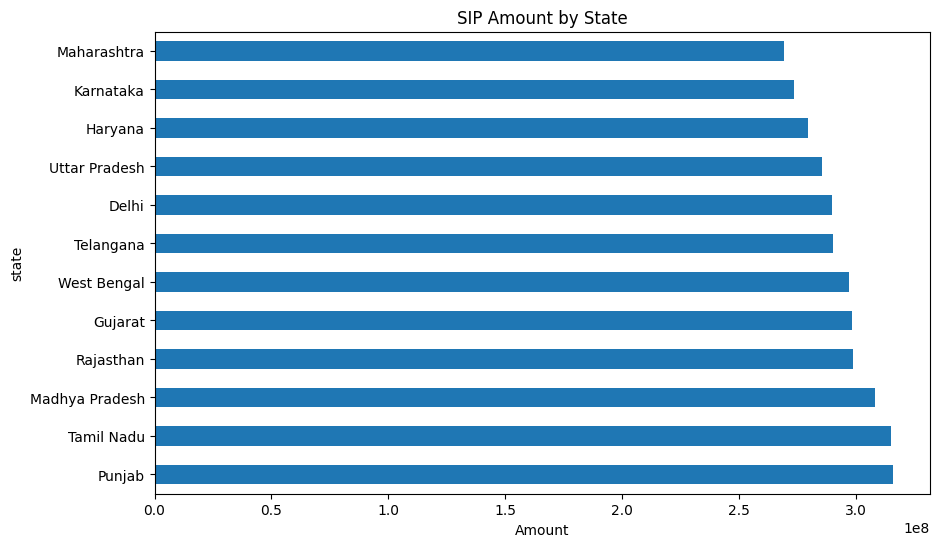

In [16]:
state_sip = transactions.groupby(

    "state"

)["amount_inr"].sum().sort_values(
    ascending=False
)

plt.figure(
    figsize=(10,6)
)

state_sip.plot(
    kind="barh"
)

plt.title(
    "SIP Amount by State"
)

plt.xlabel(
    "Amount"
)

plt.show()

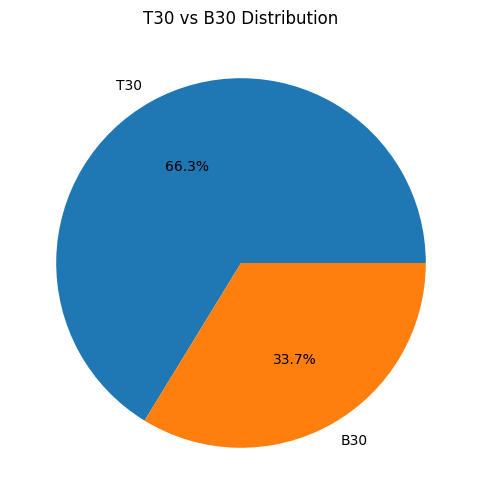

In [17]:
tier_counts = transactions[
    "city_tier"
].value_counts()

plt.figure(
    figsize=(6,6)
)

plt.pie(

    tier_counts,

    labels=tier_counts.index,

    autopct="%1.1f%%"

)

plt.title(
    "T30 vs B30 Distribution"
)

plt.show()

In [18]:
folio = sip.copy()

folio["month"] = pd.to_datetime(
    folio["month"]
)

fig = px.line(

    folio,

    x="month",

    y="active_sip_accounts_crore",

    markers=True,

    title="Folio Growth Trend"

)

fig.add_annotation(

    x=folio.iloc[0]["month"],

    y=folio.iloc[0]["active_sip_accounts_crore"],

    text="Start",

    showarrow=True

)

fig.add_annotation(

    x=folio.iloc[-1]["month"],

    y=folio.iloc[-1]["active_sip_accounts_crore"],

    text="Latest",

    showarrow=True

)

fig.show()

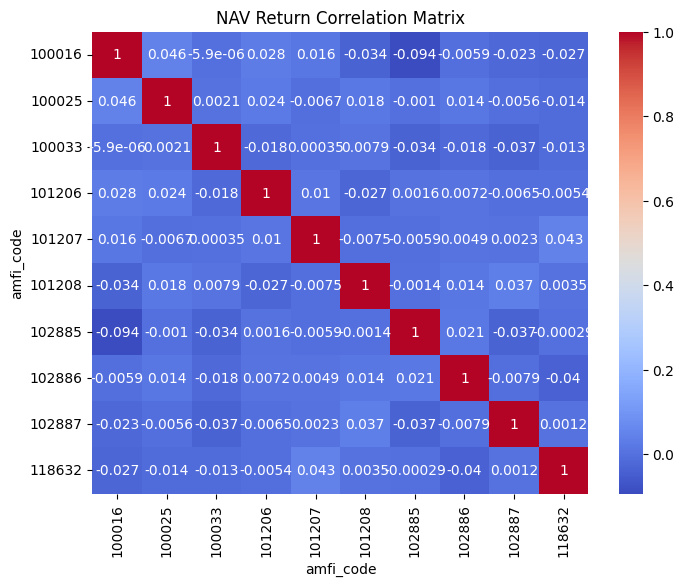

In [19]:
nav_pivot = nav_history.pivot(

    index="date",

    columns="amfi_code",

    values="nav"

)

returns = nav_pivot.pct_change()

corr = returns.iloc[
    :,
    :10
].corr()

plt.figure(
    figsize=(8,6)
)

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm"

)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.show()

In [20]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [21]:
sector_alloc = portfolio.groupby(

    "sector"

)["weight_pct"].sum().reset_index()

fig = px.pie(

    sector_alloc,

    names="sector",

    values="weight_pct",

    hole=0.5,

    title="Sector Allocation Across Equity Funds"

)

fig.show()

1. NAV trends show long-term upward movement across most schemes.

2. AUM concentration is dominated by a few major fund houses.

3. Monthly SIP inflows increased significantly between 2022 and 2025.

4. Equity funds represent a major portion of category distribution.

5. Younger age groups contribute a large share of transactions.

6. Transaction amounts vary significantly across age groups.

7. Geographic concentration exists across selected states.

8. Active SIP accounts increased consistently across years.

9. Fund return correlations indicate diversification opportunities.

10. Sector allocations show concentration toward selected industries.